<a href="https://colab.research.google.com/github/irine002/Food-Delivery-Data-Visualization-Portfolio/blob/main/Food_Delivery_Data_Visualization_Portfolio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_style("whitegrid")

# Display plots inside notebook
%matplotlib inline

Load Dataset

In [3]:
from google.colab import files

uploaded = files.upload()

Saving Day14_Food_Delivery_Visualization_Dataset.csv to Day14_Food_Delivery_Visualization_Dataset.csv


In [4]:
df = pd.read_csv("Day14_Food_Delivery_Visualization_Dataset.csv")

df.head()

,Order_Batch_ID,Date,Month,Day,City,Cuisine,Order_Channel,Weather,Orders,Average_Order_Value,Revenue,Marketing_Spend,Discounts,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
0,FD0001,2025-03-22,March,Saturday,Hyderabad,North Indian,App,Hot,156,421.03,67374.27,28150.42,7859.02,30.7,4.38,45.1
1,FD0002,2025-04-15,April,Tuesday,Chandigarh,Chinese,App,Rainy,129,371.99,50312.93,20907.75,2604.03,38.0,4.34,40.4
2,FD0003,2025-01-26,January,Sunday,Mumbai,Healthy,App,Clear,157,490.16,71929.08,18930.77,3613.92,25.3,4.65,43.0
3,FD0004,2025-06-20,June,Friday,Pune,Chinese,App,Hot,147,391.25,58803.81,35926.51,10092.64,32.6,4.48,41.2
4,FD0005,2025-08-07,August,Thursday,Bengaluru,Fast Food,Partner Platform,Rainy,172,243.76,40416.50,23514.60,2500.30,39.3,4.16,35.9


Basic Dataset Inspection

In [6]:
print("Dataset Shape:", df.shape)
df.info()
df.describe()
df.isnull().sum()
print("Duplicate rows:", df.duplicated().sum())

Dataset Shape: (360, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Order_Batch_ID           360 non-null    object 
 1   Date                     360 non-null    object 
 2   Month                    360 non-null    object 
 3   Day                      360 non-null    object 
 4   City                     360 non-null    object 
 5   Cuisine                  360 non-null    object 
 6   Order_Channel            360 non-null    object 
 7   Weather                  360 non-null    object 
 8   Orders                   360 non-null    int64  
 9   Average_Order_Value      360 non-null    float64
 10  Revenue                  360 non-null    float64
 11  Marketing_Spend          360 non-null    float64
 12  Discounts                360 non-null    float64
 13  Avg_Delivery_Minutes     360 non-null    float64
 14  C

Convert Date Column

In [7]:
df["Date"] = pd.to_datetime(df["Date"])
#Check:
print(df["Date"].dtype)

datetime64[ns]


Orders Over Time — Line Plot


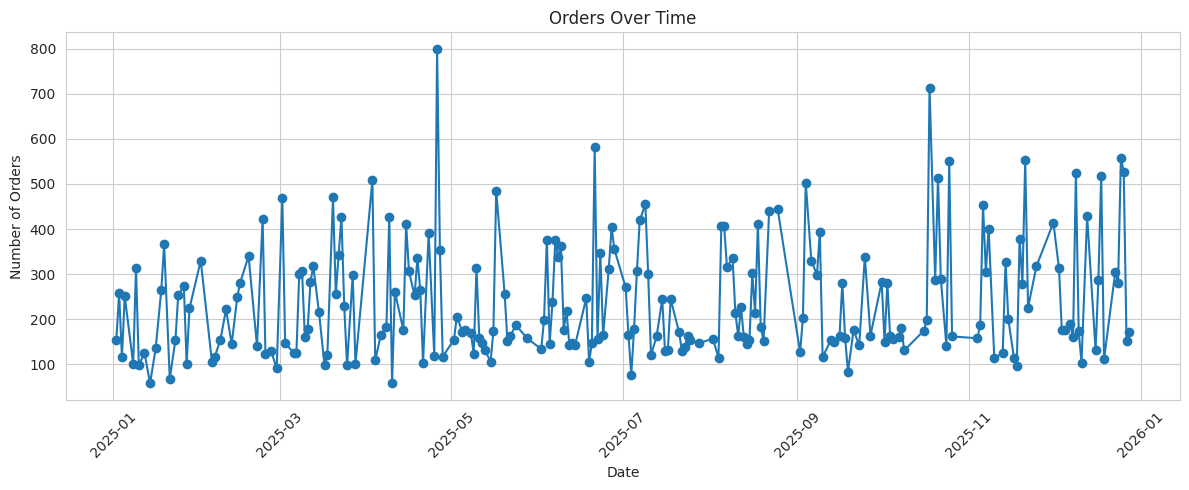

In [8]:
daily_orders = df.groupby("Date")["Orders"].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_orders.index,
    daily_orders.values,
    marker="o",
    linewidth=1.5
)

plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

The line plot shows how order volume changes over time. Peaks represent periods of higher demand, while lower points indicate comparatively weaker order activity.

Revenue Over Time — Line Plot

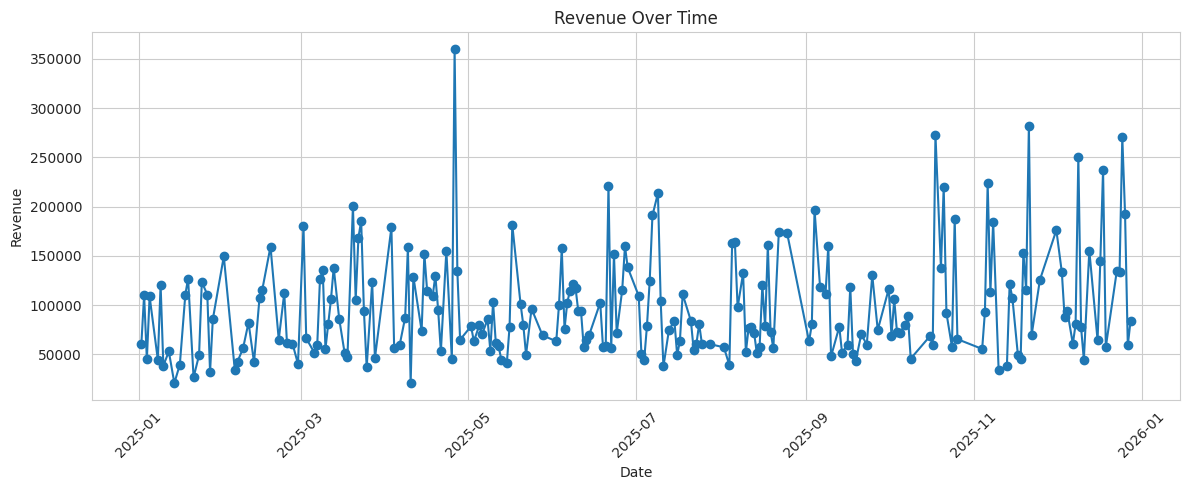

In [9]:
daily_revenue = df.groupby("Date")["Revenue"].sum()

plt.figure(figsize=(12, 5))

plt.plot(
    daily_revenue.index,
    daily_revenue.values,
    marker="o",
    linewidth=1.5
)

plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Interpretation

The chart helps identify periods when the food delivery business generated higher or lower revenue and whether revenue movements broadly follow changes in order volume.

Monthly Orders — Bar Chart

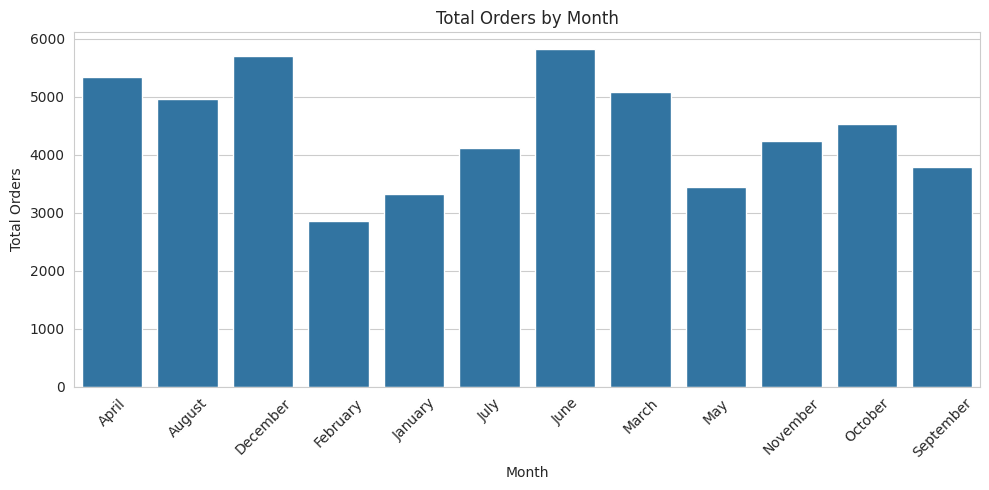

In [10]:
monthly_orders = df.groupby("Month")["Orders"].sum()

plt.figure(figsize=(10, 5))

sns.barplot(
    x=monthly_orders.index,
    y=monthly_orders.values
)

plt.title("Total Orders by Month")
plt.xlabel("Month")
plt.ylabel("Total Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


Interpretation

This chart compares order demand across months and helps identify months with particularly high or low order activity.

Revenue by City — Bar Chart

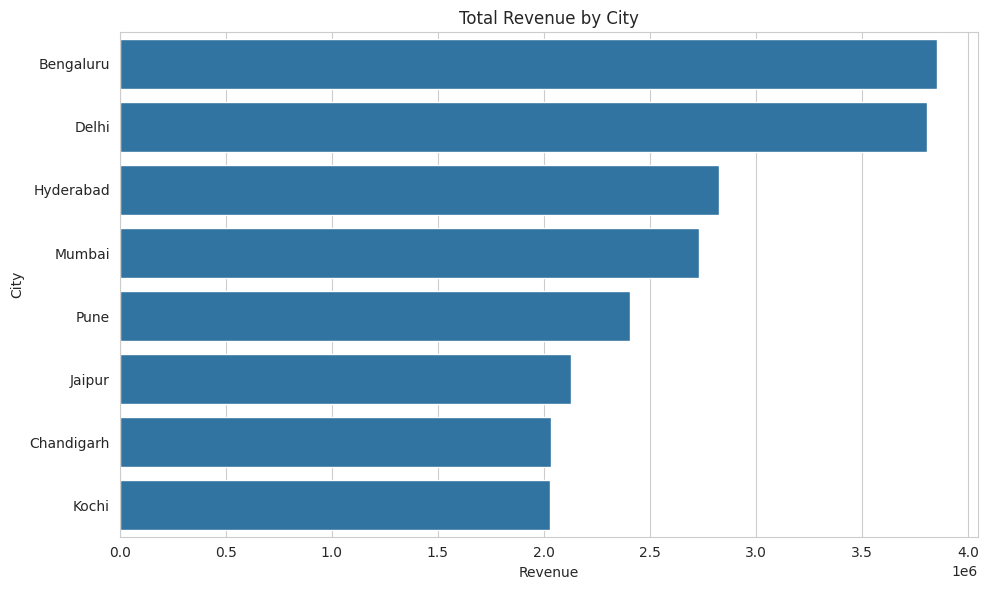

In [11]:
city_revenue = (
    df.groupby("City")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=city_revenue.values,
    y=city_revenue.index
)

plt.title("Total Revenue by City")
plt.xlabel("Revenue")
plt.ylabel("City")

plt.tight_layout()

plt.show()

Interpretation

The chart identifies the cities generating the greatest amount of revenue and allows comparison of business performance across locations.

Orders by Cuisine — Bar Chart

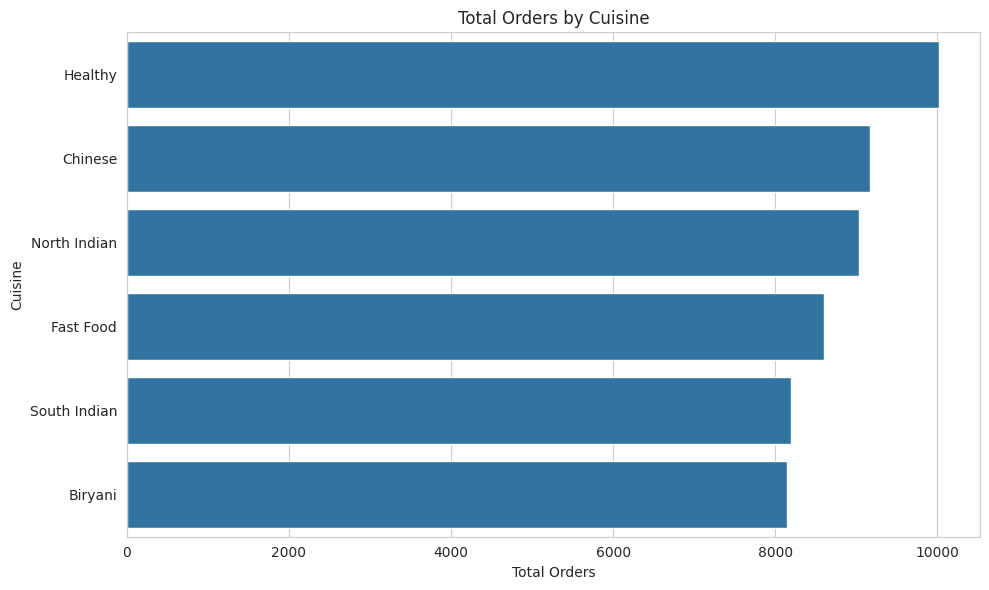

In [12]:
cuisine_orders = (
    df.groupby("Cuisine")["Orders"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=cuisine_orders.values,
    y=cuisine_orders.index
)

plt.title("Total Orders by Cuisine")
plt.xlabel("Total Orders")
plt.ylabel("Cuisine")

plt.tight_layout()

plt.show()


Interpretation

Different cuisines attract different levels of demand. The chart highlights which cuisines contribute most to overall order volume.

Marketing Spend vs Revenue — Scatter Plot

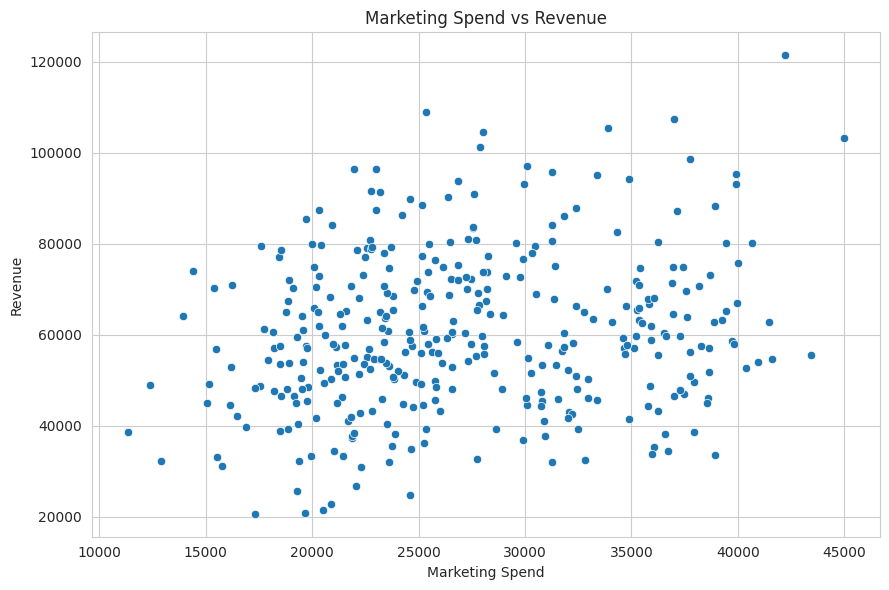

In [13]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue"
)

plt.title("Marketing Spend vs Revenue")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

Interpretation

The scatter plot helps determine whether higher marketing expenditure is associated with higher revenue. A clear upward pattern would indicate a positive relationship.

Marketing Spend vs Revenue by City

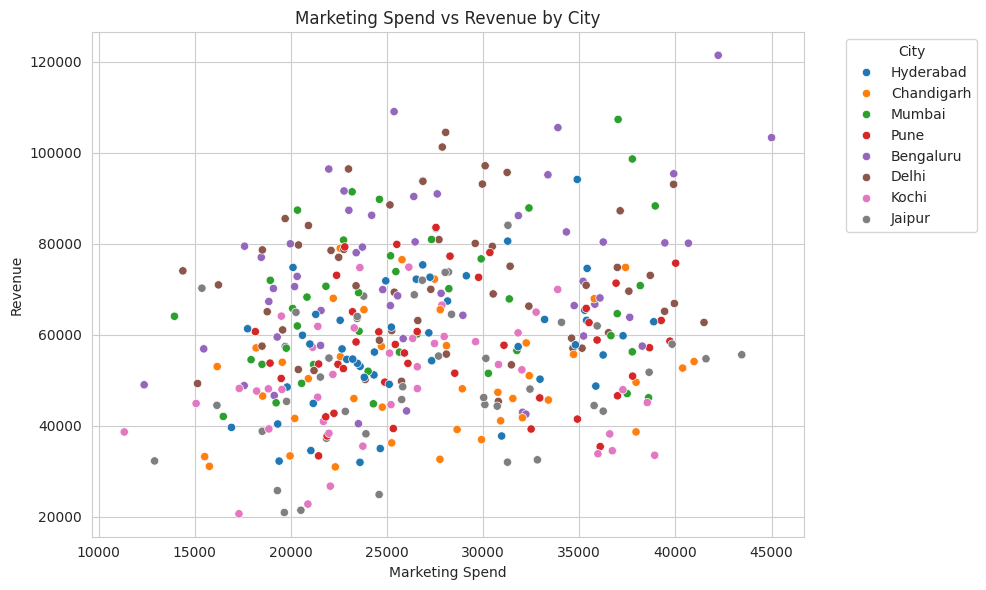

In [14]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Marketing_Spend",
    y="Revenue",
    hue="City"
)

plt.title("Marketing Spend vs Revenue by City")
plt.xlabel("Marketing Spend")
plt.ylabel("Revenue")

plt.legend(title="City", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()

plt.show()

Interpretation

Using city as the color category allows us to determine whether the relationship between marketing expenditure and revenue differs across locations.

Delivery Time vs Customer Rating

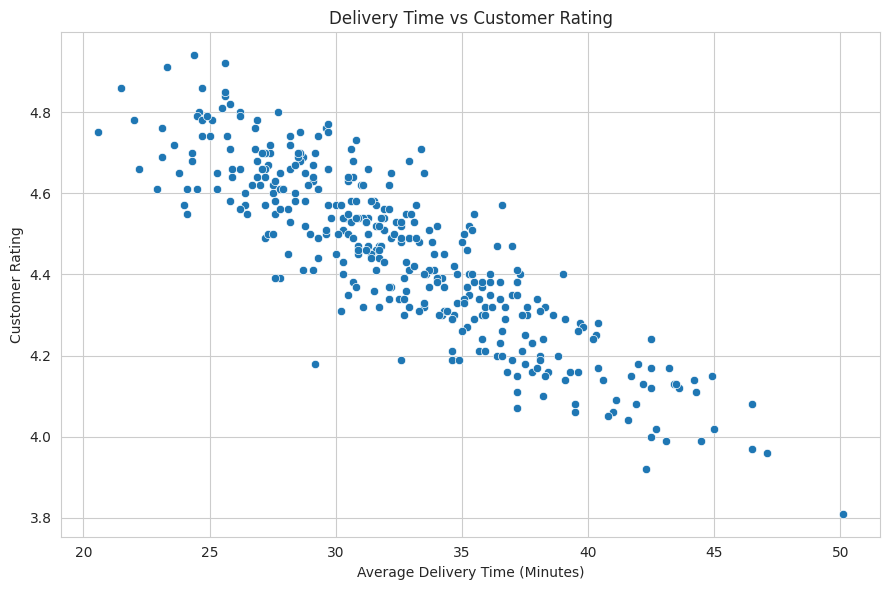

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Avg_Delivery_Minutes",
    y="Customer_Rating"
)

plt.title("Delivery Time vs Customer Rating")
plt.xlabel("Average Delivery Time (Minutes)")
plt.ylabel("Customer Rating")

plt.tight_layout()

plt.show()

Interpretation

This visualization investigates whether longer delivery times are associated with lower customer ratings. A downward pattern would suggest that slower delivery may negatively affect customer satisfaction.

Distribution of Orders — Histogram

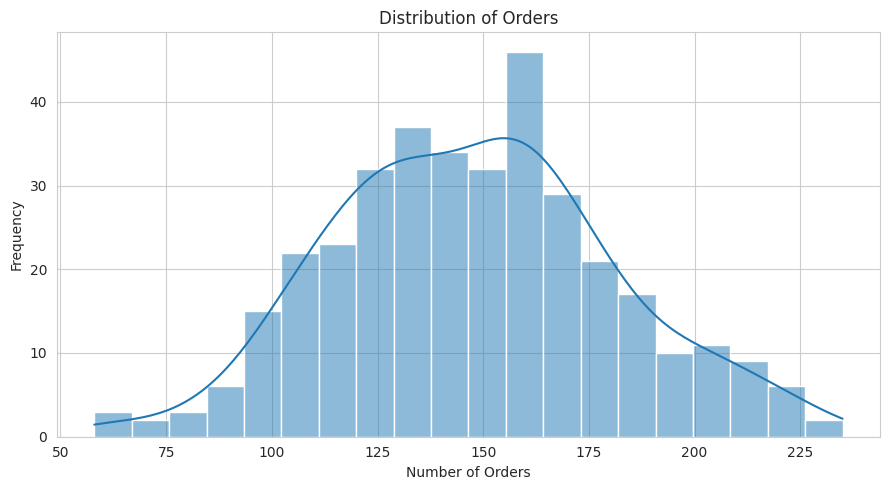

In [16]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Orders",
    bins=20,
    kde=True
)

plt.title("Distribution of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

Interpretation

The histogram shows how order volumes are distributed across the dataset and whether most observations are concentrated around a particular range.

Revenue Distribution — Histogram

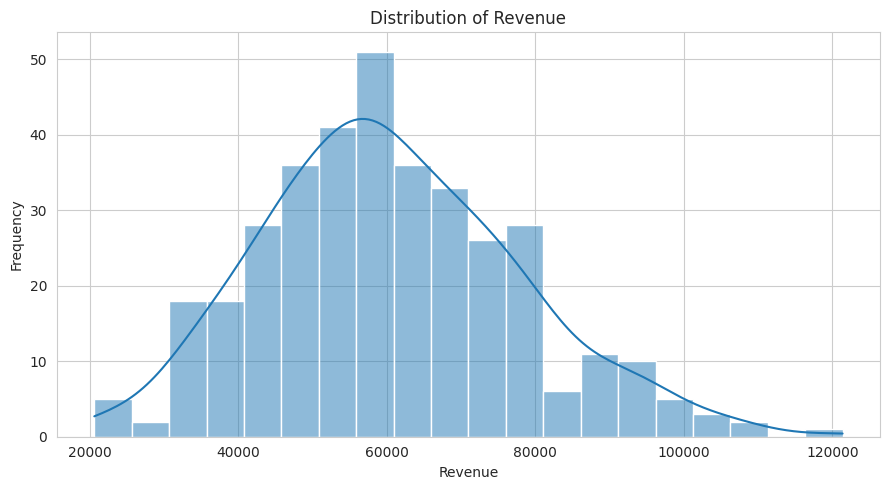

In [17]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x="Revenue",
    bins=20,
    kde=True
)

plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

Interpretation

The distribution shows the typical revenue range and helps identify unusually high or low revenue observations.

Revenue by City — Box Plot

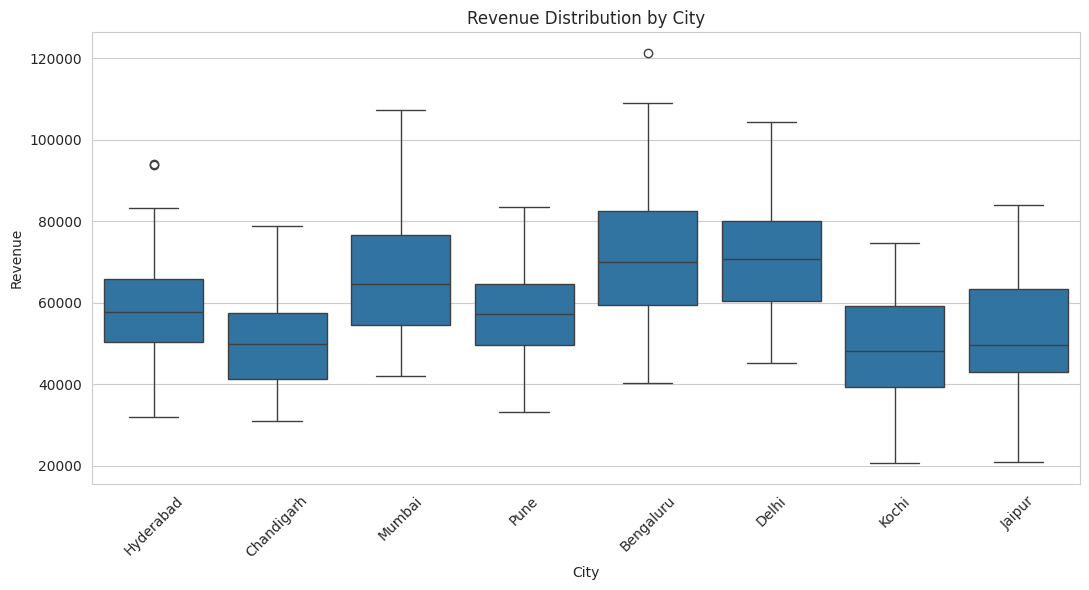

In [18]:
plt.figure(figsize=(11, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Revenue"
)

plt.title("Revenue Distribution by City")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

The box plot compares revenue distributions across cities and highlights differences in median revenue, variability, and potential outliers.

Customer Rating by Cuisine — Violin Plot

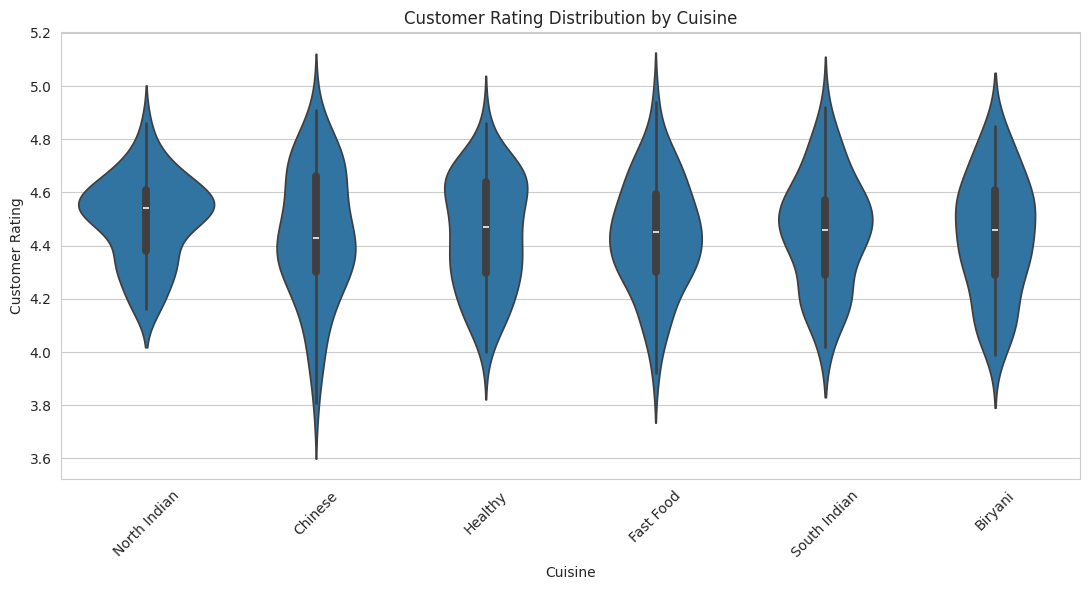

In [19]:
plt.figure(figsize=(11, 6))

sns.violinplot(
    data=df,
    x="Cuisine",
    y="Customer_Rating"
)

plt.title("Customer Rating Distribution by Cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Customer Rating")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

The violin plot shows both the distribution and concentration of customer ratings for different cuisines, making it possible to identify cuisines with consistently higher or more variable ratings.

Orders by Order Channel — Count Plot

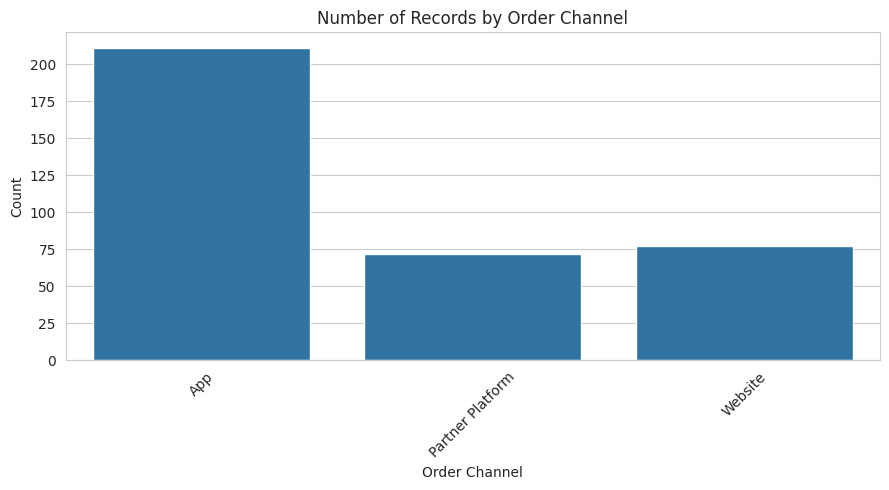

In [20]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Order_Channel"
)

plt.title("Number of Records by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Count")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

The count plot shows how frequently each order channel appears in the dataset and helps identify the dominant ordering channels.

Revenue by Order Channel

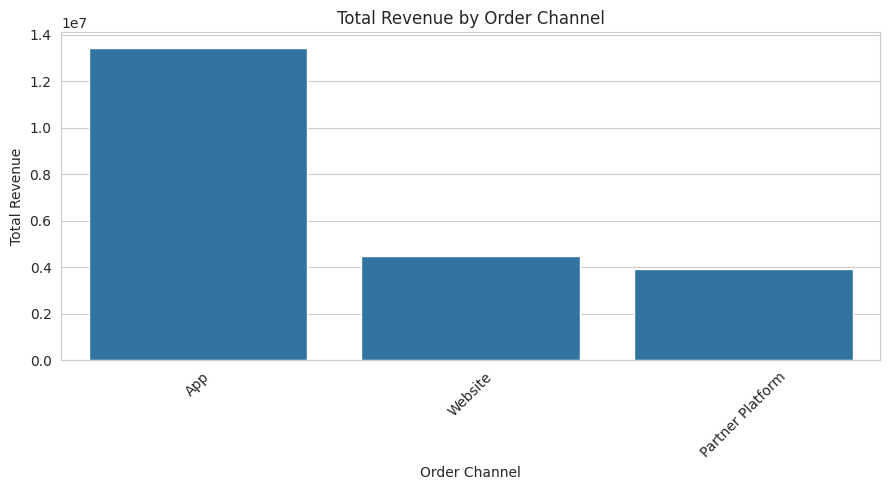

In [21]:
channel_revenue = (
    df.groupby("Order_Channel")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=channel_revenue.index,
    y=channel_revenue.values
)

plt.title("Total Revenue by Order Channel")
plt.xlabel("Order Channel")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

This visualization compares the revenue contribution of different order channels and identifies which channels generate the greatest revenue.

Weather vs Orders

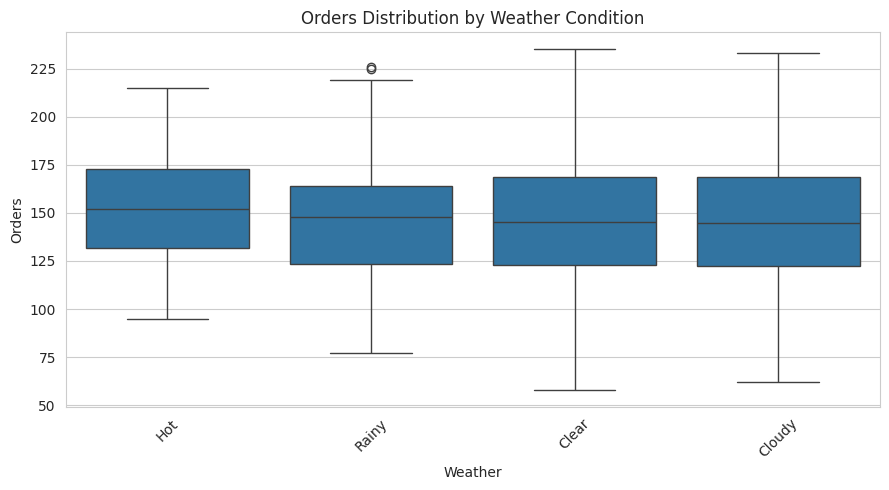

In [22]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Weather",
    y="Orders"
)

plt.title("Orders Distribution by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Orders")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

The box plot helps determine whether order volume changes under different weather conditions.

Weather vs Revenue

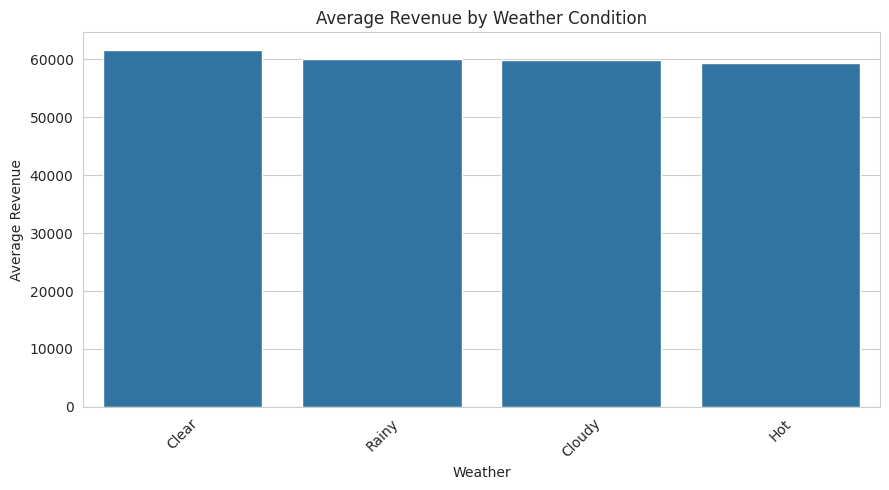

In [23]:
weather_revenue = (
    df.groupby("Weather")["Revenue"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=weather_revenue.index,
    y=weather_revenue.values
)

plt.title("Average Revenue by Weather Condition")
plt.xlabel("Weather")
plt.ylabel("Average Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

The chart compares average revenue under different weather conditions and helps identify whether weather appears to influence business performance.

Repeat Customer Percentage by City

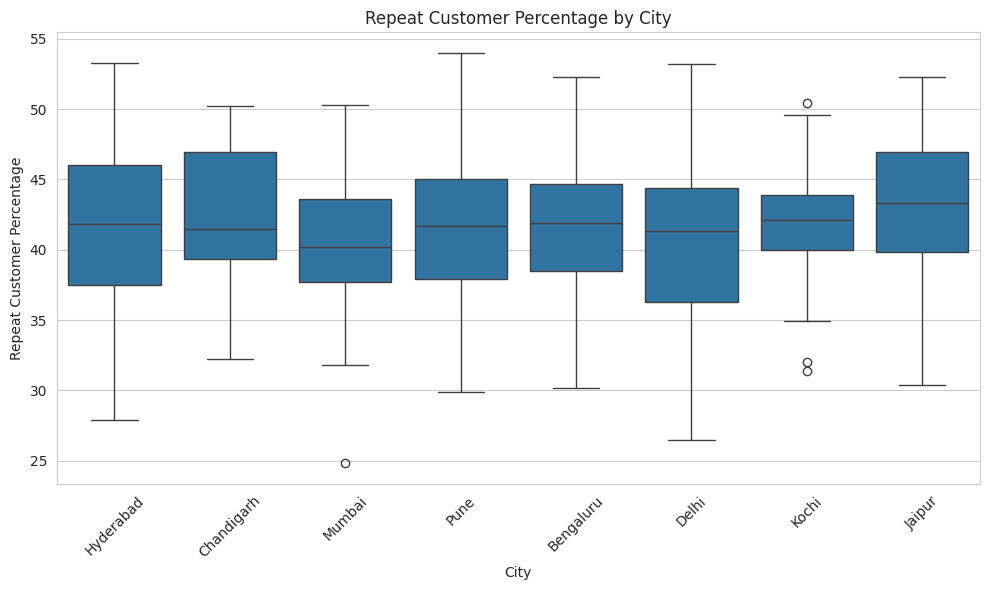

In [24]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="City",
    y="Repeat_Customer_Percent"
)

plt.title("Repeat Customer Percentage by City")
plt.xlabel("City")
plt.ylabel("Repeat Customer Percentage")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Interpretation

This chart compares customer retention across cities. Cities with higher repeat-customer percentages may have stronger customer loyalty.

Discounts vs Revenue

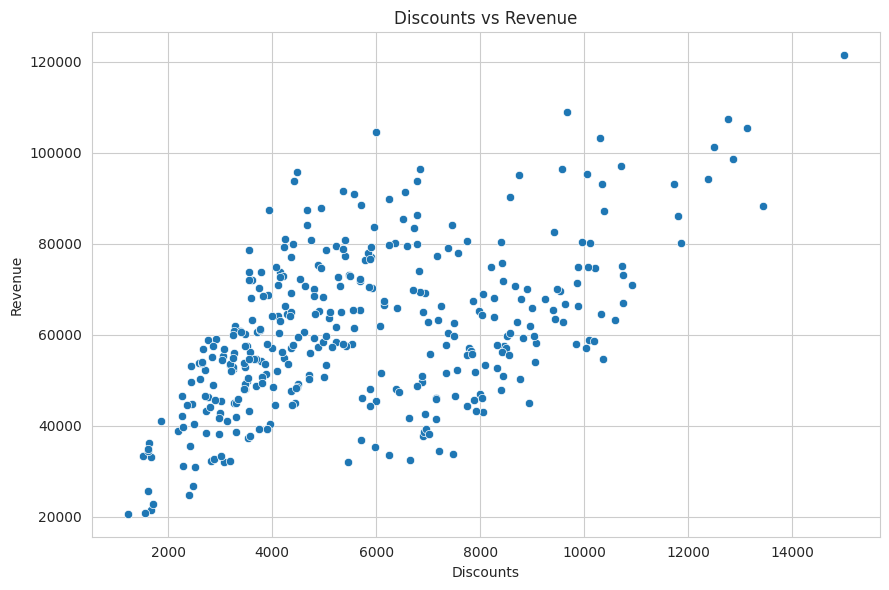

In [25]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Discounts",
    y="Revenue"
)

plt.title("Discounts vs Revenue")
plt.xlabel("Discounts")
plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

Interpretation

The scatter plot helps investigate whether higher discount levels are associated with higher revenue.

Correlation Heatmap

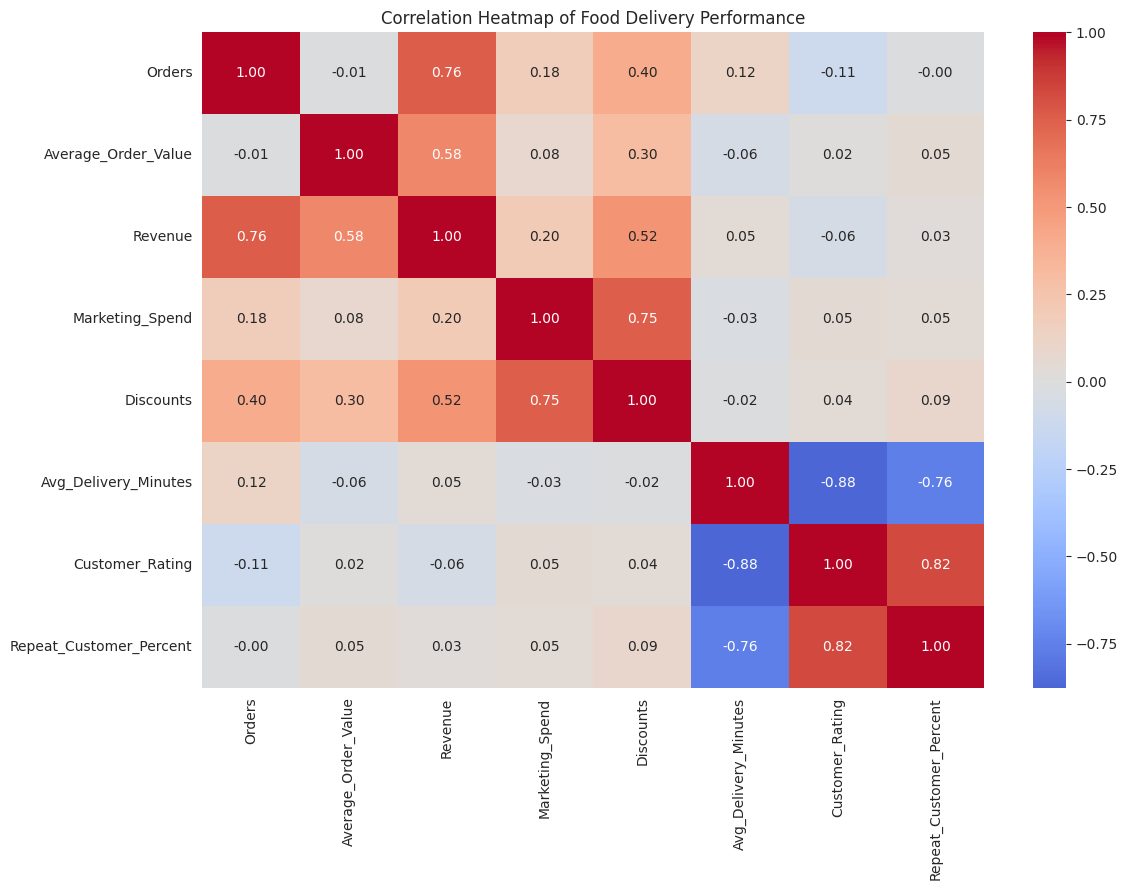

In [26]:
#Select numerical variables:

numeric_df = df.select_dtypes(include=np.number)

#Calculate correlation:

correlation = numeric_df.corr()

#Create heatmap:

plt.figure(figsize=(12, 9))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Food Delivery Performance")

plt.tight_layout()

plt.show()


Interpretation

The correlation heatmap provides an overall view of relationships between numerical variables. Strong positive or negative correlations can help identify variables that move together and may be important for understanding food delivery business performance.

Find Strongest Correlations

In [27]:
corr = numeric_df.corr()

pairs = []

columns = corr.columns

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        pairs.append(
            (
                columns[i],
                columns[j],
                corr.iloc[i, j]
            )
        )

pairs = sorted(
    pairs,
    key=lambda x: abs(x[2]),
    reverse=True
)

print("Strongest correlations:\n")

for col1, col2, value in pairs[:10]:
    print(
        f"{col1} <-> {col2}: {value:.3f}"
    )

Strongest correlations:

Avg_Delivery_Minutes <-> Customer_Rating: -0.876
Customer_Rating <-> Repeat_Customer_Percent: 0.824
Avg_Delivery_Minutes <-> Repeat_Customer_Percent: -0.760
Orders <-> Revenue: 0.760
Marketing_Spend <-> Discounts: 0.752
Average_Order_Value <-> Revenue: 0.580
Revenue <-> Discounts: 0.525
Orders <-> Discounts: 0.404
Average_Order_Value <-> Discounts: 0.298
Revenue <-> Marketing_Spend: 0.198


Average Performance by City

In [28]:
city_summary = df.groupby("City")[
    [
        "Orders",
        "Revenue",
        "Marketing_Spend",
        "Avg_Delivery_Minutes",
        "Customer_Rating",
        "Repeat_Customer_Percent"
    ]
].mean()

city_summary.round(2)

,Orders,Revenue,Marketing_Spend,Avg_Delivery_Minutes,Customer_Rating,Repeat_Customer_Percent
City,,,,,,
Bengaluru,177.25,72678.47,27377.95,33.01,4.43,41.48
Chandigarh,125.05,50860.41,27226.24,31.96,4.49,42.27
Delhi,175.25,71852.53,27836.30,33.82,4.41,40.68
Hyderabad,148.75,58841.31,26746.90,32.17,4.47,41.82
Jaipur,117.40,50696.35,27173.97,31.58,4.48,42.66
Kochi,120.80,49461.84,25694.62,31.80,4.46,41.61
Mumbai,161.78,66595.21,26568.80,33.66,4.42,40.49
Pune,138.38,57292.23,28446.48,32.21,4.47,42.04


Average Performance by Cuisine

In [29]:
cuisine_summary = df.groupby("Cuisine")[
    [
        "Orders",
        "Revenue",
        "Average_Order_Value",
        "Customer_Rating"
    ]
].mean()

cuisine_summary.round(2)

,Orders,Revenue,Average_Order_Value,Customer_Rating
Cuisine,,,,
Biryani,145.38,67145.63,458.85,4.44
Chinese,145.51,57053.40,386.09,4.44
Fast Food,148.31,46820.22,316.67,4.44
Healthy,147.41,73362.60,501.84,4.45
North Indian,148.03,64186.96,428.87,4.50
South Indian,151.65,52567.54,344.85,4.45


Average Performance by Order Channel

In [30]:
channel_summary = df.groupby("Order_Channel")[
    [
        "Orders",
        "Revenue",
        "Average_Order_Value",
        "Customer_Rating"
    ]
].mean()

channel_summary.round(2)

,Orders,Revenue,Average_Order_Value,Customer_Rating
Order_Channel,,,,
App,153.25,63675.73,414.27,4.51
Partner Platform,139.10,54251.57,391.15,4.38
Website,140.30,58066.34,411.95,4.37


Average Performance by Weather

In [31]:
weather_summary = df.groupby("Weather")[
    [
        "Orders",
        "Revenue",
        "Avg_Delivery_Minutes",
        "Customer_Rating"
    ]
].mean()

weather_summary.round(2)

,Orders,Revenue,Avg_Delivery_Minutes,Customer_Rating
Weather,,,,
Clear,147.70,61605.18,29.99,4.53
Cloudy,144.98,59935.81,31.72,4.50
Hot,152.29,59388.02,32.47,4.47
Rainy,148.11,60160.24,38.75,4.23


Final Dataset Check

In [32]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (360, 16)

Missing Values:
Order_Batch_ID             0
Date                       0
Month                      0
Day                        0
City                       0
Cuisine                    0
Order_Channel              0
Weather                    0
Orders                     0
Average_Order_Value        0
Revenue                    0
Marketing_Spend            0
Discounts                  0
Avg_Delivery_Minutes       0
Customer_Rating            0
Repeat_Customer_Percent    0
dtype: int64

Duplicate Rows: 0

Data Types:
Order_Batch_ID                     object
Date                       datetime64[ns]
Month                              object
Day                                object
City                               object
Cuisine                            object
Order_Channel                      object
Weather                            object
Orders                              int64
Average_Order_Value               float64
Revenue                      

## Final Findings

1. Order volume and revenue vary across time, indicating changes in food delivery demand during different periods.

2. Revenue performance differs across cities, showing that some locations contribute substantially more to the overall business.

3. Different cuisines show different levels of order demand, indicating differences in customer preferences.

4. Marketing spend shows a relationship with revenue, suggesting that marketing activity may be associated with stronger business performance. However, correlation does not prove causation.

5. Delivery time and customer ratings can be compared to understand whether faster deliveries are associated with better customer satisfaction.

6. Order channels contribute differently to total revenue, highlighting the importance of understanding the performance of each ordering platform.

7. Weather conditions are associated with differences in orders and revenue, showing that external conditions can influence food delivery activity.

8. The correlation heatmap reveals important relationships among orders, revenue, marketing spend, average order value, delivery time, customer ratings, and repeat-customer percentage.